In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from pathlib import Path

# PDF preserves vector paths and text; outputs are collected for the paper here.
FIGURE_DIR = Path("figure_results")
FIGURE_DIR.mkdir(exist_ok=True)
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

sns.set_theme(style="whitegrid", context="notebook")

df = pd.read_csv("experiments_results.csv")
df["group"] = df["experiment_name"].str.extract(r"(H\d)")
df["channel"] = df["experiment_name"].str.extract(r"(\d+C)")
df["prune_pct"] = pd.to_numeric(df["experiment_name"].str.extract(r"pruned(\d+)")[0])
df["pruning_type"] = df["experiment_name"].str.extract(r"(Mask|Physical)_pruning")

# One visual language throughout the notebook: colour = channel, marker = experiment group.
CHANNEL_COLORS = {
    "512C": "#1f77b4",  # blue
    "256C": "#ff7f0e",  # orange
    "128C": "#2ca02c",  # green
}
GROUP_MARKERS = {"H1": "o", "H2": "x", "H3": "s", "H4": "+"}
CHANNEL_ORDER = ["512C", "256C", "128C"]
GROUP_ORDER = ["H1", "H2", "H3", "H4"]

def add_visual_legend(ax, *, include_groups=True, loc="best", channel_marker="o"):
    channel_handles = [
        Line2D([0], [0], marker=channel_marker, color=CHANNEL_COLORS[ch], linestyle="None",
            markersize=8, markeredgewidth=1.5, label=ch,)
        for ch in CHANNEL_ORDER
    ]
    handles = channel_handles
    if include_groups:
        handles += [
            Line2D([0], [0], marker=GROUP_MARKERS[group], color="black",
                   linestyle="None", markersize=8, markeredgewidth=1.5, label=group)
            for group in GROUP_ORDER
        ]
    ax.legend(handles=handles, title="Color: channel \nMarker: configuration", loc=loc)


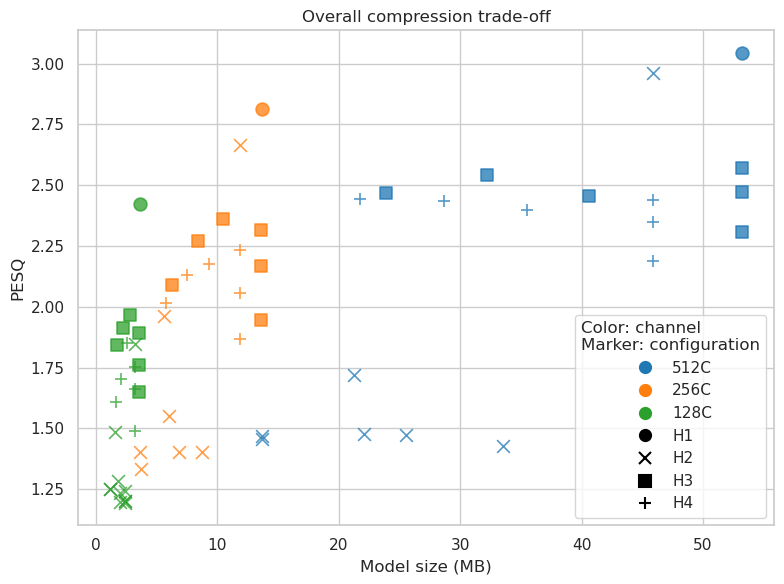

In [2]:
fig, ax = plt.subplots(figsize=(8, 6))

for group in GROUP_ORDER:
    subset = df[df["group"] == group]
    for channel in CHANNEL_ORDER:
        points = subset[subset["channel"] == channel]
        ax.scatter(points["model_size_mb"], points["pesq"], color=CHANNEL_COLORS[channel],
                   marker=GROUP_MARKERS[group], s=85, alpha=0.75, linewidths=1.2)

ax.set(xlabel="Model size (MB)", ylabel="PESQ", title="Overall compression trade-off")
add_visual_legend(ax, loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "overall_model_size_pesq.pdf", format="pdf", bbox_inches="tight")
plt.show()


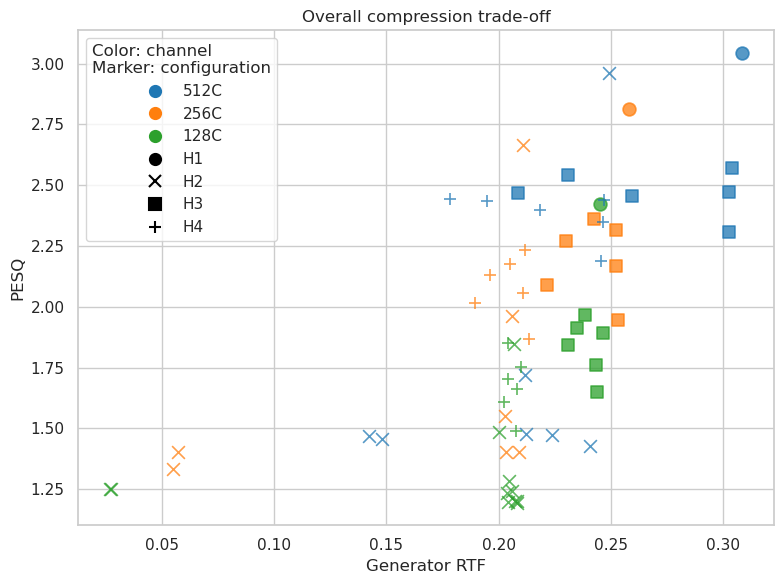

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

for group in GROUP_ORDER:
    subset = df[df["group"] == group]
    for channel in CHANNEL_ORDER:
        points = subset[subset["channel"] == channel]
        ax.scatter(points["avg_generator_rtf"], points["pesq"], color=CHANNEL_COLORS[channel],
                   marker=GROUP_MARKERS[group], s=85, alpha=0.75, linewidths=1.2)

ax.set(xlabel="Generator RTF", ylabel="PESQ", title="Overall compression trade-off")
add_visual_legend(ax, loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "overall_generator_rtf_pesq.pdf", format="pdf", bbox_inches="tight")
plt.show()


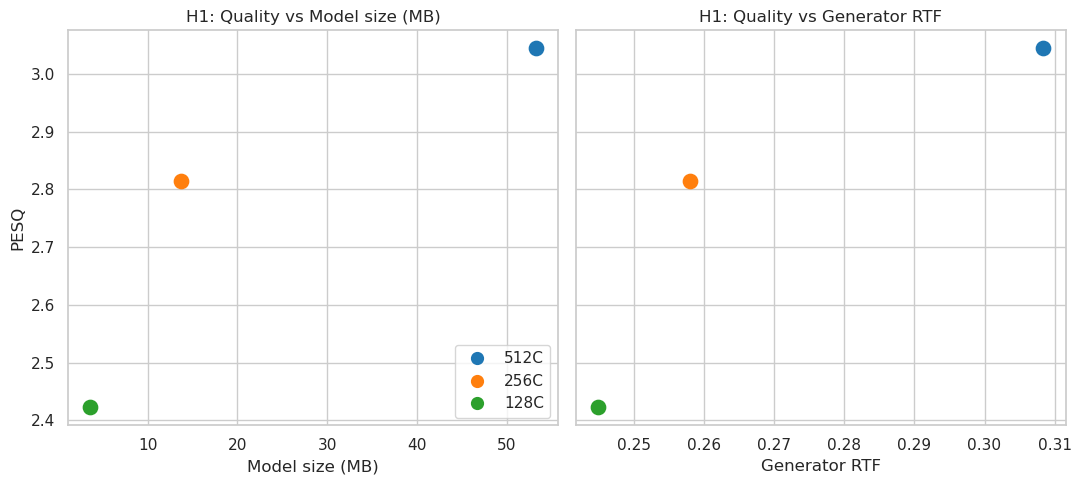

In [4]:
h1 = df[df["group"] == "H1"].copy()
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for channel in CHANNEL_ORDER:
    point = h1[h1["channel"] == channel]
    for i, (ax, x_column, x_label) in enumerate(zip(
        axes,["model_size_mb", "avg_generator_rtf"],["Model size (MB)", "Generator RTF"]
    )):
        ax.scatter(point[x_column], point["pesq"], color=CHANNEL_COLORS[channel],
                   marker=GROUP_MARKERS["H1"], s=100, linewidths=1.3)
        ax.set_xlabel(x_label)
        ax.set_title(f"H1: Quality vs {x_label}")
        
add_visual_legend(axes[0], include_groups=False,loc="lower right")
axes[0].get_legend().set_title(None)
axes[0].set_ylabel("PESQ")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "h1_quality_tradeoffs.pdf", format="pdf", bbox_inches="tight")
plt.show()


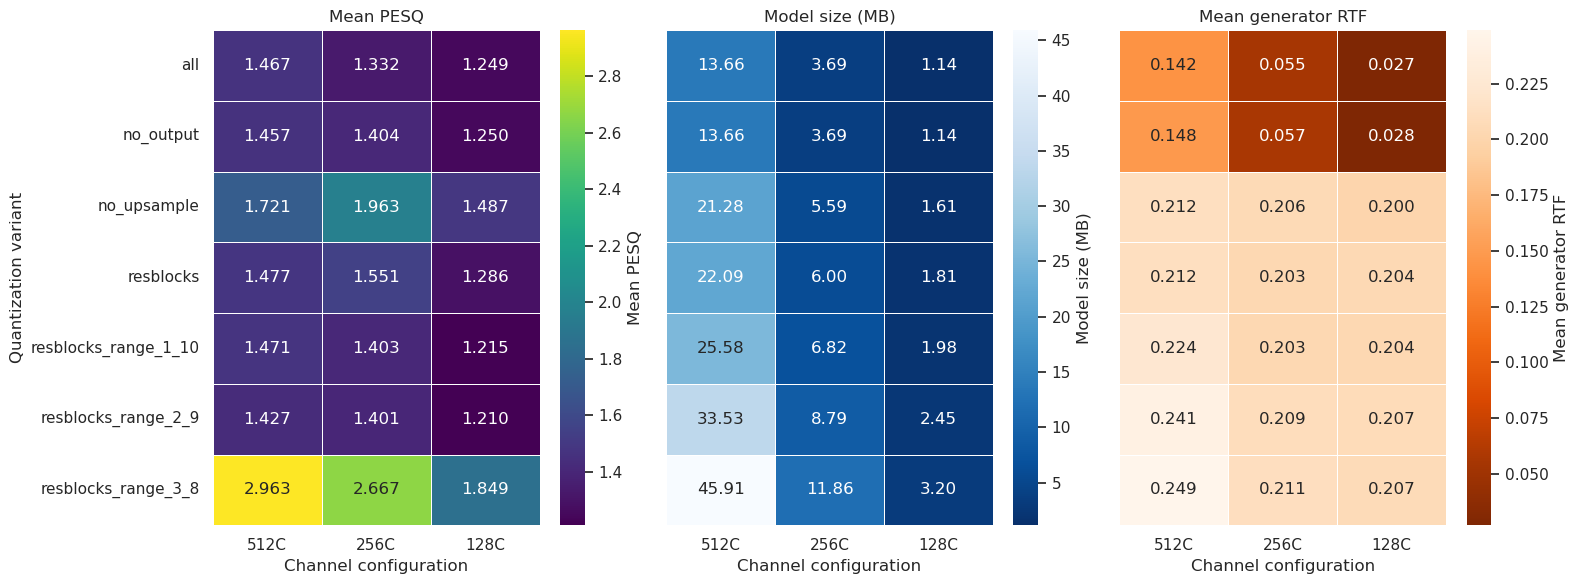

In [5]:
h2 = df[df["group"] == "H2"].copy()
h2["variant"] = h2["experiment_name"].str.extract(
    r"quantized_(all|no_output|no_upsample|resblocks_range_\d+_\d+|resblocks)"
)
variant_order = [
    "all", "no_output", "no_upsample", "resblocks",
    "resblocks_range_1_10", "resblocks_range_2_9", "resblocks_range_3_8",
]

metrics = {
    "pesq": ("Mean PESQ", "viridis", ".3f"),
    "model_size_mb": ("Model size (MB)", "Blues_r", ".2f"),
    "avg_generator_rtf": ("Mean generator RTF", "Oranges_r", ".3f"),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

for ax, (metric, (label, cmap, value_format)) in zip(axes, metrics.items()):
    heatmap_data = h2.pivot_table(
        index="variant",
        columns="channel",
        values=metric,
        aggfunc="mean",
    ).reindex(index=variant_order, columns=CHANNEL_ORDER).dropna(how="all")

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=value_format,
        cmap=cmap,
        linewidths=0.7,
        cbar_kws={"label": label},
        ax=ax,
    )
    ax.set_xlabel("Channel configuration")
    ax.set_title(label)

axes[0].set_ylabel("Quantization variant")
axes[1].set_ylabel("")
axes[2].set_ylabel("")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "h2_quantization_heatmaps.pdf", format="pdf", bbox_inches="tight")
plt.show()

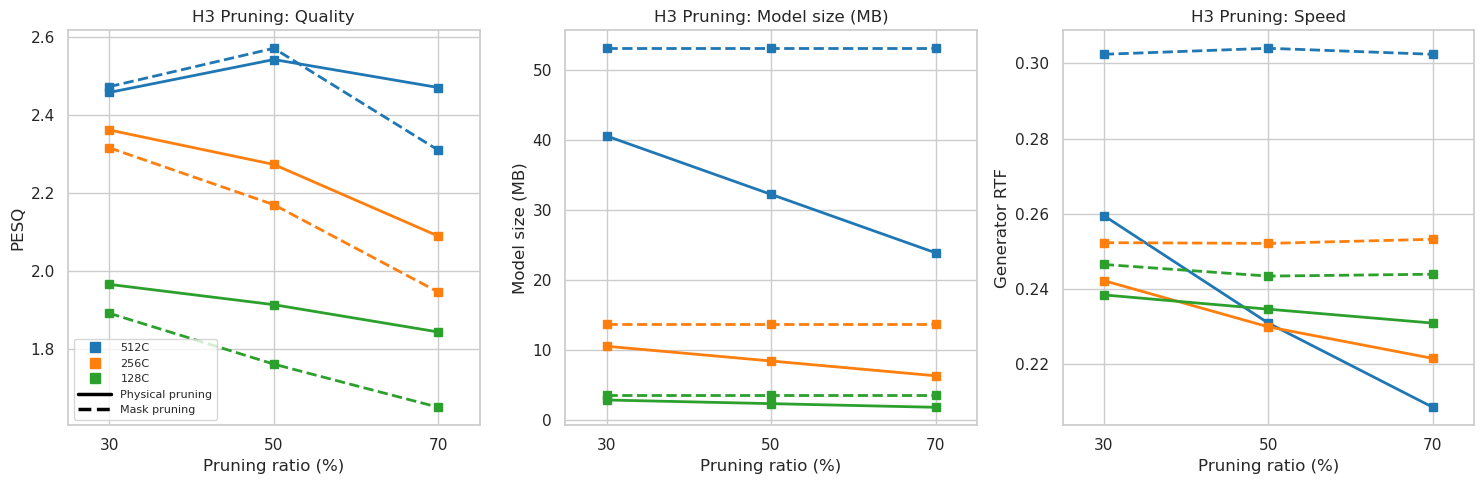

In [6]:
from matplotlib.lines import Line2D
# Ordered pruning: colour remains channel, marker remains H3; pruning method is line style only.
h3 = df[df["group"] == "H3"].copy()
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True)
metrics = [("pesq", "PESQ"), ("model_size_mb", "Model size (MB)"),
           ("avg_generator_rtf", "Generator RTF")]
line_styles = {"Physical": "-", "Mask": "--"}

for channel in CHANNEL_ORDER:
    for pruning_type, line_style in line_styles.items():
        series = h3[(h3["channel"] == channel) & (h3["pruning_type"] == pruning_type)].sort_values("prune_pct")
        for ax, (metric, ylabel) in zip(axes, metrics):
            ax.plot(series["prune_pct"], series[metric], color=CHANNEL_COLORS[channel],
                    marker=GROUP_MARKERS["H3"], linestyle=line_style, linewidth=2,
                    markersize=6, label=f"{channel} — {pruning_type}")
            ax.set(ylabel=ylabel, xlabel="Pruning ratio (%)")

axes[0].set_title("H3 Pruning: Quality")
axes[1].set_title("H3 Pruning: Model size (MB)")
axes[2].set_title("H3 Pruning: Speed")


legend_handles = [
    # channel: colour
    Line2D([0], [0], color=CHANNEL_COLORS["512C"], marker=GROUP_MARKERS["H3"],
           linestyle="None", markersize=7, label="512C"),
    Line2D([0], [0], color=CHANNEL_COLORS["256C"], marker=GROUP_MARKERS["H3"],
           linestyle="None", markersize=7, label="256C"),
    Line2D([0], [0], color=CHANNEL_COLORS["128C"], marker=GROUP_MARKERS["H3"],
           linestyle="None", markersize=7, label="128C"),

    # pruning method: line style
    Line2D([0], [0], color="black", linestyle="-", linewidth=2.5,
           label="Physical pruning"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=2.5,
           label="Mask pruning"),
]

axes[0].legend(handles=legend_handles,fontsize=8,loc="lower left",handlelength=3)

for ax in axes:
    ax.set_xticks([30, 50, 70])
    ax.set_xticklabels(["30", "50", "70"])
    ax.set_xlim(25, 75)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "h3_ordered_pruning.pdf", format="pdf", bbox_inches="tight")
plt.show()


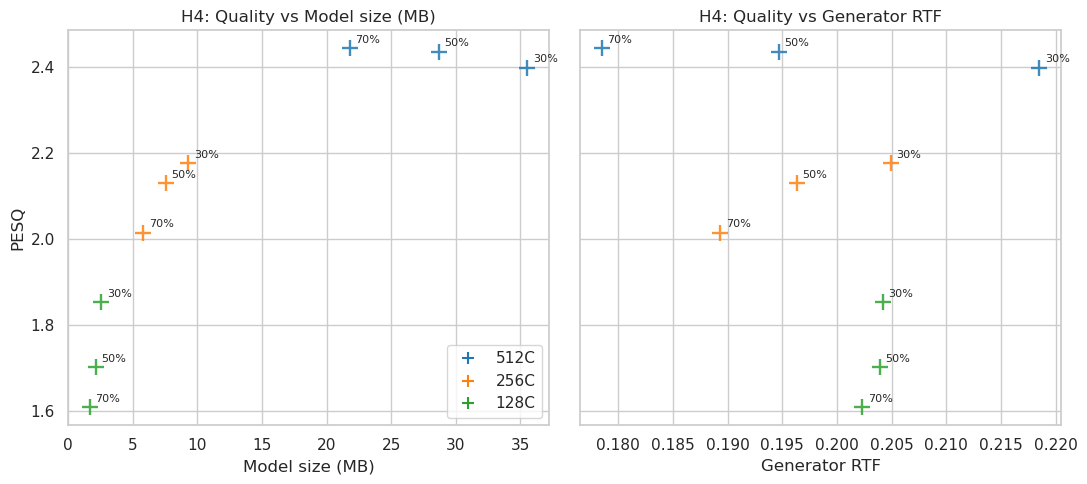

In [7]:
# Physical-pruning H4 points are shown here; the line plot above shows both pruning methods clearly.
h4 = df[(df["group"] == "H4") & (df["pruning_type"] == "Physical")].copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

plot_settings = [
    ("model_size_mb", "Model size (MB)"),
    ("avg_generator_rtf", "Generator RTF"),
]

for ax, (x_column, x_label) in zip(axes, plot_settings):
    for channel in CHANNEL_ORDER:
        points = h4[h4["channel"] == channel]

        ax.scatter(
            points[x_column],
            points["pesq"],
            color=CHANNEL_COLORS[channel],
            marker=GROUP_MARKERS["H4"],
            s=120,
            alpha=0.85,
            linewidths=1.7,
        )

        for _, row in points.iterrows():
            ax.annotate(
                f"{int(row['prune_pct'])}%",
                (row[x_column], row["pesq"]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
            )

    ax.set_xlabel(x_label)
    ax.set_title(f"H4: Quality vs {x_label}")

axes[0].set_ylabel("PESQ")

add_visual_legend(
    axes[0],
    include_groups=False,
    loc="lower right",
    channel_marker=GROUP_MARKERS["H4"],
)
axes[0].get_legend().set_title(None)

plt.tight_layout()
fig.savefig(FIGURE_DIR / "h4_hybrid_compression.pdf", format="pdf", bbox_inches="tight")
plt.show()

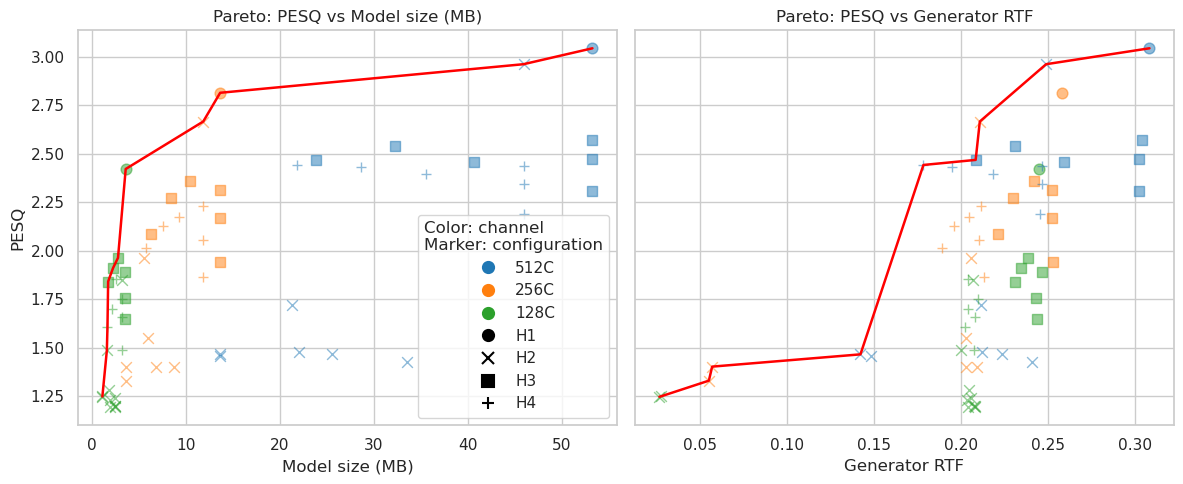

In [8]:
def pareto_frontier(data, x_column, y_column):
    ordered = data.sort_values([x_column, y_column], ascending=[True, False])
    return ordered[ordered[y_column].cummax().eq(ordered[y_column])].drop_duplicates(subset=x_column)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, x_column, x_label in zip(
    axes,
    ["model_size_mb", "avg_generator_rtf"],
    ["Model size (MB)", "Generator RTF"],
):
    for group in GROUP_ORDER:
        for channel in CHANNEL_ORDER:
            points = df[(df["group"] == group) & (df["channel"] == channel)]
            ax.scatter(
                points[x_column],
                points["pesq"],
                color=CHANNEL_COLORS[channel],
                marker=GROUP_MARKERS[group],
                s=60,
                alpha=0.5,
                linewidths=1.0,
            )

    pareto = pareto_frontier(df, x_column, "pesq")
    ax.plot(pareto[x_column], pareto["pesq"], color="red", linewidth=1.8, label="Pareto frontier")
    ax.set(xlabel=x_label, title=f"Pareto: PESQ vs {x_label}")

axes[0].set_ylabel("PESQ")
add_visual_legend(axes[0], loc="best")

plt.tight_layout()
fig.savefig(FIGURE_DIR / "pareto_frontiers.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [10]:
# Summary uses a same-channel H1 baseline, except channel scaling, which uses 512C H1 as reference.
baselines = df[df["group"] == "H1"].set_index("channel")
baseline_512 = baselines.loc["512C"]

summary_parts = []

# Channel scaling against the full 512C H1 model.
channel_scaling = df[df["group"] == "H1"].copy()
channel_scaling["comparison"] = "Channel scaling (vs H1 512C)"
channel_scaling["reference"] = "H1_512C_baseline"
channel_scaling["reference_size_mb"] = baseline_512["model_size_mb"]
channel_scaling["reference_rtf"] = baseline_512["avg_generator_rtf"]
channel_scaling["reference_pesq"] = baseline_512["pesq"]
channel_scaling["reference_stoi"] = baseline_512["stoi"]
summary_parts.append(channel_scaling)

# Use the H2/H4 resblocks 3–8 configuration so the quantization comparison matches the hybrid setup.
h2_summary = df[(df["group"] == "H2") & df["experiment_name"].str.contains("resblocks_range_3_8")].copy()
h2_summary["comparison"] = "H2 quantization 3-8 (vs same-channel H1)"

h3_summary = df[(df["group"] == "H3") & (df["pruning_type"] == "Physical")].copy()
h3_summary["comparison"] = "H3 physical pruning (vs same-channel H1)"

h4_summary = df[(df["group"] == "H4") & (df["pruning_type"] == "Physical")].copy()
h4_summary["comparison"] = "H4 pruning + quantization (vs same-channel H1)"

for part in [h2_summary, h3_summary, h4_summary]:
    part["reference"] = part["channel"].map(baselines["experiment_name"])
    part["reference_size_mb"] = part["channel"].map(baselines["model_size_mb"])
    part["reference_rtf"] = part["channel"].map(baselines["avg_generator_rtf"])
    part["reference_pesq"] = part["channel"].map(baselines["pesq"])
    part["reference_stoi"] = part["channel"].map(baselines["stoi"])
    summary_parts.append(part)

improvement_summary = pd.concat(summary_parts, ignore_index=True)
improvement_summary["size_reduction_mb"] = improvement_summary["reference_size_mb"] - improvement_summary["model_size_mb"]
improvement_summary["size_reduction_pct"] = 100 * improvement_summary["size_reduction_mb"] / improvement_summary["reference_size_mb"]
improvement_summary["rtf_reduction"] = improvement_summary["reference_rtf"] - improvement_summary["avg_generator_rtf"]
improvement_summary["rtf_reduction_pct"] = 100 * improvement_summary["rtf_reduction"] / improvement_summary["reference_rtf"]
improvement_summary["pesq_change"] = improvement_summary["pesq"] - improvement_summary["reference_pesq"]
improvement_summary["pesq_change_pct"] = 100 * improvement_summary["pesq_change"] / improvement_summary["reference_pesq"]
improvement_summary["stoi_change"] = (improvement_summary["stoi"] - improvement_summary["reference_stoi"])
improvement_summary["stoi_change_pct"] = (100 * improvement_summary["stoi_change"] / improvement_summary["reference_stoi"])

summary_table = improvement_summary[[
    "comparison", "experiment_name", "reference", "channel", "prune_pct",
    "size_reduction_mb", "size_reduction_pct", "rtf_reduction", "rtf_reduction_pct",
    "pesq_change", "pesq_change_pct","stoi_change", "stoi_change_pct"
]].rename(columns={
    "prune_pct": "pruning_pct", "size_reduction_mb": "size_reduction_MB",
    "size_reduction_pct": "size_reduction_%", "rtf_reduction": "generator_RTF_reduction",
    "rtf_reduction_pct": "generator_RTF_reduction_%", "pesq_change": "PESQ_change",
    "pesq_change_pct": "PESQ_change_%", "stoi_change": "STOI_change","stoi_change_pct": "STOI_change_%"
})

summary_table = summary_table.round({
    "size_reduction_MB": 3, "size_reduction_%": 1, "generator_RTF_reduction": 4,
    "generator_RTF_reduction_%": 1, "PESQ_change": 3, "PESQ_change_%": 1, "STOI_change": 4, "STOI_change_%": 2
})

print(
    "Positive reduction values indicate a smaller/faster model; "
    "positive PESQ/STOI values indicate higher quality."
)

comparison_order = [
    "Channel scaling (vs H1 512C)",
    "H2 quantization 3-8 (vs same-channel H1)",
    "H3 physical pruning (vs same-channel H1)",
    "H4 pruning + quantization (vs same-channel H1)",
]

summary_table["comparison"] = pd.Categorical(
    summary_table["comparison"],
    categories=comparison_order,
    ordered=True,
)

summary_table["channel"] = pd.Categorical(
    summary_table["channel"],
    categories=["512C", "256C", "128C"],
    ordered=True,
)

summary_table_sorted = summary_table.sort_values(
    ["comparison", "channel", "pruning_pct"],
    na_position="first",
)
summary_table_sorted.to_csv(FIGURE_DIR / "summary_table.csv", index=False)
summary_table_sorted.to_latex(
    FIGURE_DIR / "summary_table.tex",
    index=False,
    na_rep="",
    escape=True,
    caption="Absolute and relative improvements for channel scaling, quantization, and pruning.",
    label="tab:compression_summary",
)
display(summary_table_sorted)



Positive reduction values indicate a smaller/faster model; positive PESQ/STOI values indicate higher quality.


,comparison,experiment_name,reference,channel,pruning_pct,size_reduction_MB,size_reduction_%,generator_RTF_reduction,generator_RTF_reduction_%,PESQ_change,PESQ_change_%,STOI_change,STOI_change_%
2,Channel scaling (vs H1 512C),H1_512C_baseline,H1_512C_baseline,512C,NaN,0.000,0.0,0.0000,0.0,0.000,0.0,0.0000,0.00
0,Channel scaling (vs H1 512C),H1_256C_baseline,H1_512C_baseline,256C,NaN,39.579,74.3,0.0504,16.3,-0.229,-7.5,-0.0101,-1.05
1,Channel scaling (vs H1 512C),H1_128C_baseline,H1_512C_baseline,128C,NaN,49.622,93.2,0.0635,20.6,-0.622,-20.4,-0.0282,-2.93
5,H2 quantization 3-8 (vs same-channel H1),H2_512C_quantized_resblocks_range_3_8,H1_512C_baseline,512C,NaN,7.329,13.8,0.0594,19.3,-0.082,-2.7,-0.0035,-0.36
4,H2 quantization 3-8 (vs same-channel H1),H2_256C_quantized_resblocks_range_3_8,H1_256C_baseline,256C,NaN,1.799,13.2,0.0471,18.3,-0.148,-5.3,-0.0063,-0.67
3,H2 quantization 3-8 (vs same-channel H1),H2_128C_quantized_resblocks_range_3_8,H1_128C_baseline,128C,NaN,0.417,11.5,0.0380,15.5,-0.574,-23.7,-0.0292,-3.13
8,H3 physical pruning (vs same-channel H1),H3_512C_pruned30_Physical_pruning,H1_512C_baseline,512C,30.0,12.620,23.7,0.0489,15.9,-0.588,-19.3,-0.0253,-2.64
11,H3 physical pruning (vs same-channel H1),H3_512C_pruned50_Physical_pruning,H1_512C_baseline,512C,50.0,20.989,39.4,0.0775,25.1,-0.503,-16.5,-0.0180,-1.87
14,H3 physical pruning (vs same-channel H1),H3_512C_pruned70_Physical_pruning,H1_512C_baseline,512C,70.0,29.361,55.1,0.0999,32.4,-0.575,-18.9,-0.0248,-2.58
7,H3 physical pruning (vs same-channel H1),H3_256C_pruned30_Physical_pruning,H1_256C_baseline,256C,30.0,3.163,23.2,0.0158,6.1,-0.455,-16.2,-0.0211,-2.21
